# Une nouvelle forme de clustering avec réduction de dimensionnalité

On utilise ici la technique proposée dans l'article suivant : "USING CHROMA HISTOGRAM TO MEASURE THE PERCEPTUAL SIMILARITY OF
MUSIC", disponible à l'adresse https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=4607685.
Cette version nettoie ce qui a été fait dans l'optique de renvoyer une liste de centroïdes par compositeur.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
from plotly.offline import plot
import plotly.io as pio
from sklearn.manifold import MDS
import librosa
from scipy.cluster.hierarchy import linkage, dendrogram
import os
import warnings
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def verbose(message, verbose_level, verbose_threshold=0):
    if verbose_level > verbose_threshold:
        print(message)

In [3]:
li_composer = ["Bach","Beethoven","Brahms","Dvorak","Haendel","Haydn","Mendelssohn","Mozart","Rameau","Schubert","Chostakovitch"]

## Réduction de dimensionnalité

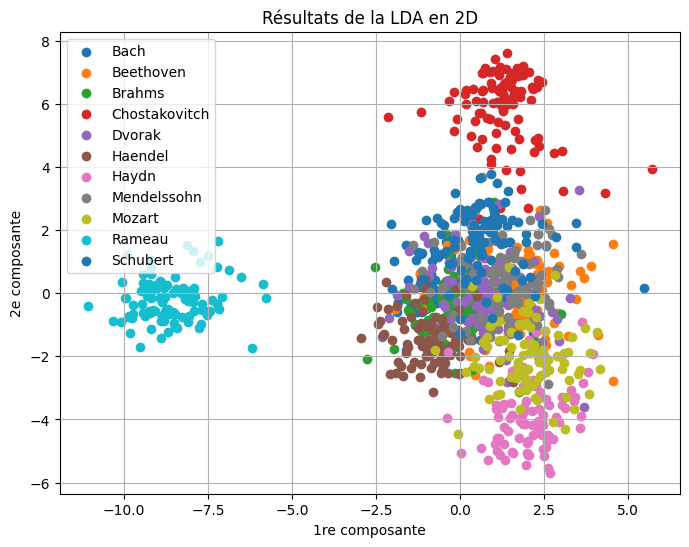

In [4]:
X = []
y = []
for composer in li_composer:
    file = "hist_" + composer + ".pkl"
    with open(file, "rb") as f:
        dic_composer = pickle.load(f)
        for k, v in dic_composer.items():
            matrice = np.vstack(v)
            X.append(matrice.flatten())
            y.append(composer)
X = np.array(X)
y = np.array(y)

# Normalisation des données

lda = LDA(n_components=2) 
X_lda = lda.fit_transform(X, y)

# Visualiser les résultats
plt.figure(figsize=(8, 6))
for class_label in np.unique(y):
    plt.scatter(X_lda[y == class_label, 0], X_lda[y == class_label, 1], label=class_label)

plt.title('Résultats de la LDA en 2D')
plt.xlabel('1re composante')
plt.ylabel('2e composante')
plt.legend()
plt.grid()
plt.show()

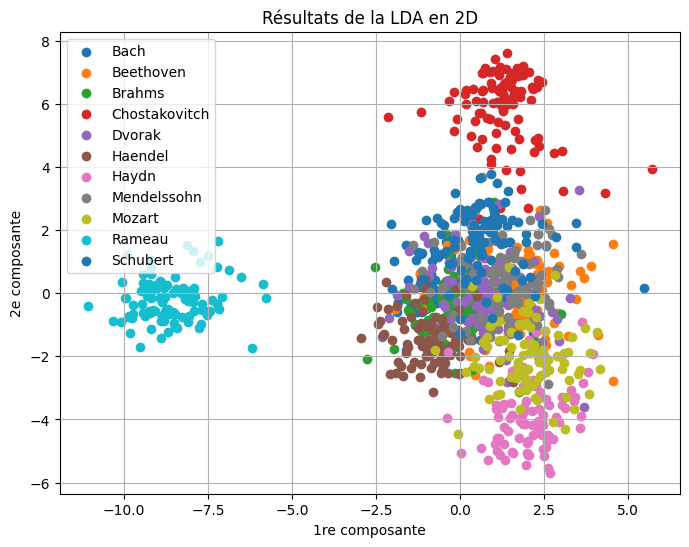

In [5]:
X = []
y = []
for composer in li_composer:
    file = "hist_" + composer + ".pkl"
    with open(file, "rb") as f:
        dic_composer = pickle.load(f)
        for k, v in dic_composer.items():
            matrice = np.vstack(v)
            X.append(matrice.flatten())
            y.append(composer)
X = np.array(X)
y = np.array(y)

# Normalisation des données
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

lda = LDA(n_components=2) 
X_lda = lda.fit_transform(X_normalized, y)

# Visualiser les résultats
plt.figure(figsize=(8, 6))
for class_label in np.unique(y):
    plt.scatter(X_lda[y == class_label, 0], X_lda[y == class_label, 1], label=class_label)

plt.title('Résultats de la LDA en 2D')
plt.xlabel('1re composante')
plt.ylabel('2e composante')
plt.legend()
plt.grid()
plt.show()

In [6]:
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X_normalized, y)

df = pd.DataFrame(data=X_lda, columns=['1re composante', '2e composante', '3e composante'])
df['Class'] = [i for i in y]

fig = px.scatter_3d(df, x='1re composante', y='2e composante', z='3e composante',
                    color='Class', title='Résultats de la LDA en 3D',
                    labels={'Class': 'Compositeur'},
                    color_discrete_sequence=px.colors.qualitative.Set1)

fig.show()

## Essai du SVM

In [7]:
import numpy as np
import plotly.graph_objects as go
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Générer des données d'exemple avec des labels de chaînes
# Appliquer LDA pour réduire la dimensionnalité à 3
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X, y)

# Entraîner un SVM sur les données transformées
svm = SVC(kernel='linear', probability=True)
svm.fit(X_lda, y)

# Créer une grille pour prédire les zones
x_min, x_max = X_lda[:, 0].min() - 1, X_lda[:, 0].max() + 1
y_min, y_max = X_lda[:, 1].min() - 1, X_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Prédire les classes sur la grille
Z = svm.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())])  # On fixe la troisième dimension à 0
Z = Z.reshape(xx.shape)

# Liste de 10 couleurs
colors_list = [
    "#FF5733",  # Rouge
    "#33FF57",  # Vert
    "#3357FF",  # Bleu
    "#F1C40F",  # Jaune
    "#8E44AD",  # Violet
    "#E67E22",  # Orange
    "#2ECC71",  # Vert clair
    "#3498DB",  # Bleu clair
    "#E74C3C",  # Rouge clair
    "#95A5A6",  # Gris
    "#FFC300"   # Jaune doré
]
# Créer un mappage des labels à des indices
unique_labels = list(set(y))  # Obtenir les labels uniques
label_to_index = {label: index for index, label in enumerate(unique_labels)}  # Dictionnaire de mappage
print(len(unique_labels))
# Mapper les couleurs aux labels
color_labels = [colors_list[label_to_index[label]] for label in y]

# Tracer les zones de prédiction
fig = go.Figure()

# Ajouter les zones de prédiction
fig.add_trace(go.Contour(z=Z, x=xx[0], y=yy[:, 0], colorscale='Viridis', opacity=0.5, showscale=False))

# Ajouter les points d'origine avec les couleurs associées
fig.add_trace(go.Scatter3d(x=X_lda[:, 0], y=X_lda[:, 1], z=X_lda[:, 2], mode='markers', 
                             marker=dict(color=color_labels, size=5)))

# Configurer le layout
fig.update_layout(scene=dict(xaxis_title='LDA Component 1',
                              yaxis_title='LDA Component 2',
                              zaxis_title='LDA Component 3'),
                  title='Zones de Prédiction avec LDA et SVM')

# Afficher le graphique
fig.show()


11


In [8]:
import numpy as np
import plotly.graph_objects as go
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder

# Appliquer LDA pour réduire la dimensionnalité à 3
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X, y)

# Entraîner un SVM sur les données transformées
svm = SVC(kernel='sigmoid', probability=True)
svm.fit(X_lda, y)

# Créer une grille pour prédire les zones
x_min, x_max = X_lda[:, 0].min() - 1, X_lda[:, 0].max() + 1
y_min, y_max = X_lda[:, 1].min() - 1, X_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Prédire les classes sur la grille
Z = svm.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())])  # On fixe la troisième dimension à 0
Z = Z.reshape(xx.shape)

# Liste de 11 couleurs
colors_list = [
    "#FF5733",  # Rouge
    "#33FF57",  # Vert
    "#3357FF",  # Bleu
    "#F1C40F",  # Jaune
    "#8E44AD",  # Violet
    "#E67E22",  # Orange
    "#2ECC71",  # Vert clair
    "#3498DB",  # Bleu clair
    "#E74C3C",  # Rouge clair
    "#95A5A6",  # Gris
    "#FFC300"   # Jaune doré
]

# Créer un mappage des labels à des indices
unique_labels = list(set(y))  # Obtenir les labels uniques
label_to_index = {label: index for index, label in enumerate(unique_labels)}  # Dictionnaire de mappage

# Mapper les couleurs aux labels
color_labels = [colors_list[label_to_index[label]] for label in y]

# Tracer les zones de prédiction
fig = go.Figure()

# Ajouter les zones de décision
for i, label in enumerate(unique_labels):
    # Créer un masque pour chaque classe
    mask = (Z == label)  # Créer un masque pour la classe
    fig.add_trace(go.Surface(z=mask.astype(float), x=xx[0], y=yy[:, 0], colorscale=[[0, colors_list[i]], [1, colors_list[i]]], showscale=False, name=label, opacity=0.2))

# Ajouter les points d'origine avec les couleurs associées
fig.add_trace(go.Scatter3d(x=X_lda[:, 0], y=X_lda[:, 1], z=X_lda[:, 2], mode='markers', 
                             marker=dict(color=color_labels, size=5)))


# Ajouter des traces pour la légende des compositeurs
for i, label in enumerate(unique_labels):
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers', 
        marker=dict(color=colors_list[i], size=10), 
        name=label  # Nom du compositeur pour la légende
    ))

# Configurer le layout
fig.update_layout(scene=dict(xaxis_title='LDA Component 1',
                              yaxis_title='LDA Component 2',
                              zaxis_title='LDA Component 3'),
                legend = dict(title='Compositeurs'),
                  title='Zones de Prédiction avec LDA et SVM')

# Afficher le graphique
fig.show()


## Tentative avec du clustering

### Une première approche

In [9]:
from sklearn.cluster import KMeans

# Apply k-means clustering
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X, y)
kmeans = KMeans(n_clusters=11, random_state=42)
clusters = kmeans.fit_predict(X_lda)

# Add cluster information to the dataframe
df['Cluster'] = clusters

# Map cluster numbers to marker symbols for visualization
marker_symbols = ['circle', 'square', 'diamond', 'cross', 'x', 'triangle-up', 'triangle-down', 'triangle-left', 'triangle-right', 'pentagon', 'hexagon']
df['Marker'] = df['Cluster'].map(lambda cluster: marker_symbols[cluster])

# Plot the result
fig = px.scatter_3d(df, x='1re composante', y='2e composante', z='3e composante',
                    color='Class', symbol='Marker', title='K-Means Clustering with LDA in 3D',
                    labels={'Class': 'Compositeur'},
                    color_discrete_sequence=px.colors.qualitative.Set1)

# Create a 3D mesh grid for boundary decisions
x_range = np.linspace(X_lda[:, 0].min() - 1, X_lda[:, 0].max() + 1, 50)
y_range = np.linspace(X_lda[:, 1].min() - 1, X_lda[:, 1].max() + 1, 50)
z_range = np.linspace(X_lda[:, 2].min() - 1, X_lda[:, 2].max() + 1, 50)
xx, yy, zz = np.meshgrid(x_range, y_range, z_range)

# Predict cluster labels for each point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
grid_labels = kmeans.predict(grid_points)
grid_labels = grid_labels.reshape(xx.shape)

# Add the boundary decisions to the plot
fig = px.scatter_3d(df, x='1re composante', y='2e composante', z='3e composante',
                    color='Class', symbol='Marker', title='K-Means Clustering with LDA in 3D',
                    labels={'Class': 'Compositeur'},
                    color_discrete_sequence=px.colors.qualitative.Set1)

# Add the decision boundaries as a 3D surface
fig.add_trace(go.Volume(
    x=xx.ravel(),
    y=yy.ravel(),
    z=zz.ravel(),
    value=grid_labels.ravel(),
    isomin=0,
    isomax=10,
    opacity=0.1,  # Adjust opacity for better visualization
    surface_count=11,  # Number of cluster boundaries
    colorscale='Viridis',
    showscale=False
))

fig.show()

# Count the number of data points in each cluster for each composer
cluster_composer_counts = df.groupby(['Cluster', 'Class']).size().unstack(fill_value=0)

In [10]:
cluster_composer_counts

Class,Bach,Beethoven,Brahms,Chostakovitch,Dvorak,Haendel,Haydn,Mendelssohn,Mozart,Rameau,Schubert
Cluster,,,,,,,,,,,
0,0,0,24,0,2,87,0,1,0,0,0
1,0,1,54,0,9,9,0,6,0,0,3
2,77,7,0,0,2,0,1,2,1,0,2
3,0,0,0,0,0,0,0,0,0,99,0
4,0,0,0,0,0,0,91,0,0,0,0
5,2,10,0,0,3,0,6,4,82,0,1
6,3,7,3,2,8,0,0,26,1,0,66
7,0,0,0,91,0,0,0,0,0,0,0
8,11,12,10,0,26,0,0,14,2,0,15


<Axes: xlabel='Class', ylabel='Cluster'>

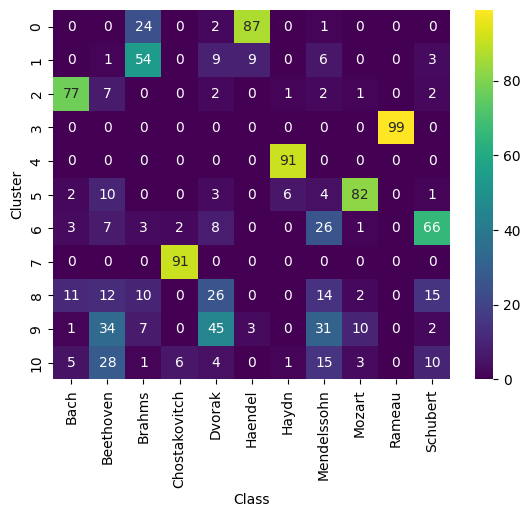

In [11]:
import seaborn as sns
sns.heatmap(cluster_composer_counts, annot=True, fmt='d', cmap='viridis')

### Estimation du meilleur espace LDA

<Axes: xlabel='Class', ylabel='Cluster'>

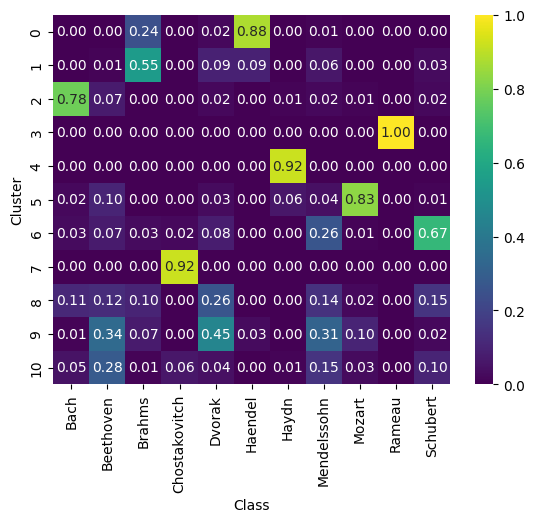

In [12]:
cluster_counts = np.array(cluster_composer_counts)  # Ensure cluster_counts is a numpy array
total_counts = np.sum(cluster_counts, axis=0)
probabilities = cluster_counts / total_counts[:, np.newaxis]
probabilities = cluster_composer_counts / total_counts[:, np.newaxis]
sns.heatmap(probabilities, annot=True, fmt='.2f', cmap='viridis')

In [13]:
def calcul_entropy(cluster_counts, axe = 1):
    """Calcule l'entropie moyenne de chaque cluster.
    Si axe = 1, calcule l'entropie pour chaque cluster.
    Sinon, calcule l'entropie pour chaque compositeur.
    """
    cluster_counts = np.array(cluster_counts)  # Ensure cluster_counts is a numpy array
    total_counts = np.sum(cluster_counts, axis=axe)
    probabilities = cluster_counts / total_counts[:, np.newaxis]
    probabilities[total_counts == 0] = 1  # Éviter la division par zéro
    with np.errstate(divide='ignore', invalid='ignore'):
        log_probabilities = np.log(probabilities, where=(probabilities > 0))
        entropy = -np.nansum(probabilities * log_probabilities)
    return entropy

In [14]:
def clustering(X,y,n_compos, n_clusters=11):
    """Effectue un clustering sur les données X et y avec n_clusters."""
    # Normalisation des données
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)

    # Appliquer LDA pour réduire la dimensionnalité à 3
    lda = LDA(n_components=n_compos)
    X_lda = lda.fit_transform(X_normalized, y)

    # Appliquer KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(X_lda)

    # Créer un DataFrame pour la visualisation
    df = pd.DataFrame(data=X_lda)
    df['Compositeur'] = [i for i in y]
    df['Cluster'] = clusters

    cluster_composer_counts = df.groupby(['Cluster', 'Compositeur']).size().unstack(fill_value=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Heatmap for cluster-composer counts
    sns.heatmap(cluster_composer_counts, annot=True, fmt='d', cmap='viridis', ax=axes[0])
    axes[0].set_title("Matrice de confusion (Cluster vs Compositeur)")

    # Heatmap for classification errors by cluster
    cluster_counts = np.array(cluster_composer_counts)  # Ensure cluster_counts is a numpy array
    total_counts = np.sum(cluster_counts, axis=1)
    probabilities = cluster_counts / total_counts[:, np.newaxis]
    probabilities = cluster_composer_counts / total_counts[:, np.newaxis]
    sns.heatmap(probabilities, annot=True, fmt='.2f', cmap='viridis', ax=axes[1])
    axes[1].set_title(f"Erreurs de classification par cluster (entropie: {calcul_entropy(cluster_counts, axe=1):.3f})")

    # Heatmap for classification errors by composer
    total_counts = np.sum(cluster_counts, axis=0)
    probabilities = cluster_counts / total_counts[:, np.newaxis]
    probabilities = cluster_composer_counts / total_counts[:, np.newaxis]
    sns.heatmap(probabilities, annot=True, fmt='.2f', cmap='viridis', ax=axes[2])
    axes[2].set_title(f"Erreurs de classification par compositeur (entropie : {calcul_entropy(cluster_counts, axe=0):.3f})")

    plt.tight_layout()
    plt.show()
    #return df

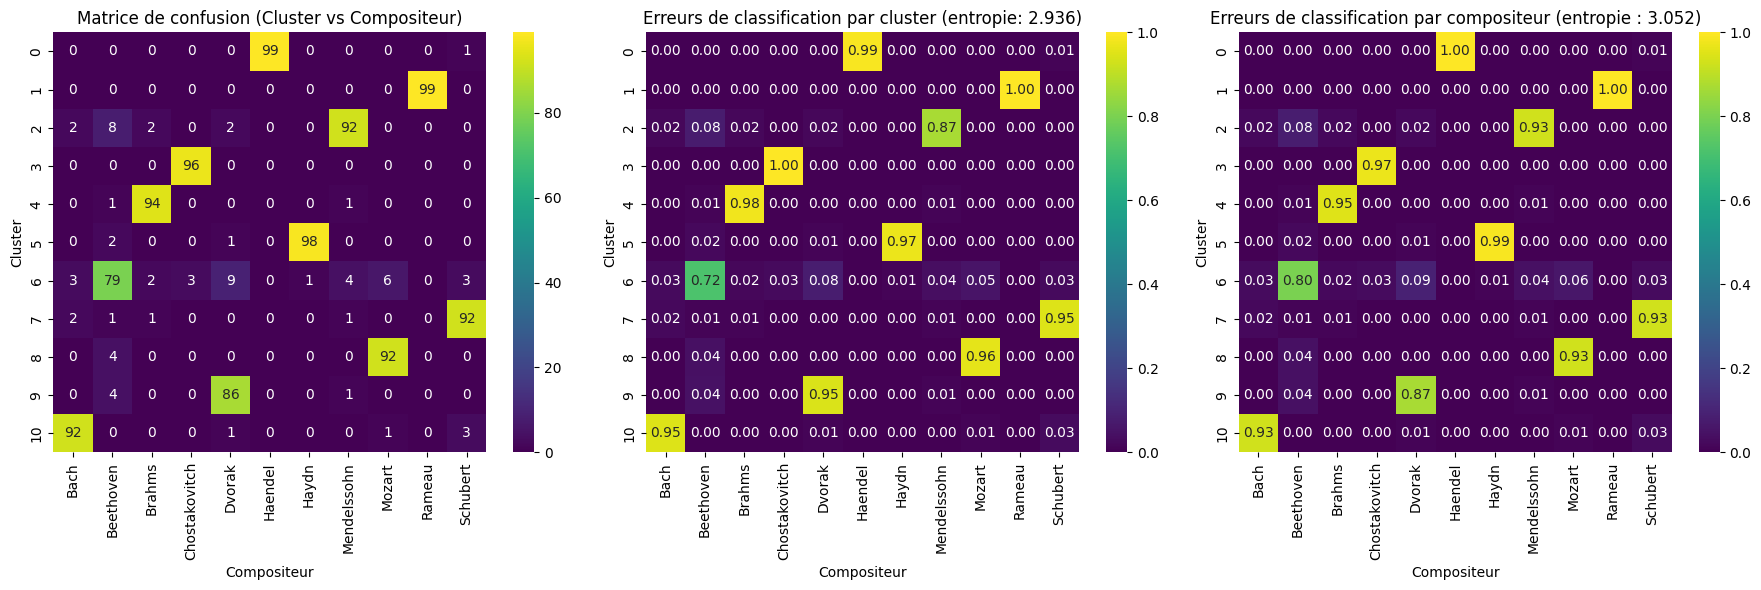

In [15]:
clustering(X,y,7)

In [16]:
def clustering_test(X,y,n_compos, n_clusters=11):
    """Effectue un clustering sur les données X et y avec n_clusters."""
    # Normalisation des données
    scaler = StandardScaler()
    X_normalized = scaler.fit_transform(X)

    # Appliquer LDA pour réduire la dimensionnalité à 3
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    X_train_lda = lda.fit_transform(X_train, y_train)
    X_test_lda = lda.transform(X_test)
    
    # Appliquer KMeans sur l'ensemble d'entraînement
    kmeans = KMeans(n_clusters=11, random_state=42)
    clusters = kmeans.fit_predict(X_train_lda)
    
    # Prédire les clusters pour l'ensemble de test
    test_clusters = kmeans.predict(X_test_lda)
    
    # Créer un DataFrame pour l'ensemble de test
    df_test = pd.DataFrame(data=X_test_lda)
    df_test['Compositeur'] = y_test
    df_test['Cluster'] = test_clusters

    cluster_composer_counts = df_test.groupby(['Cluster', 'Compositeur']).size().unstack(fill_value=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Heatmap for cluster-composer counts
    sns.heatmap(cluster_composer_counts, annot=True, fmt='d', cmap='viridis', ax=axes[0])
    axes[0].set_title("Matrice de confusion (Cluster vs Compositeur)")

    # Heatmap for classification errors by cluster
    cluster_counts = np.array(cluster_composer_counts)  # Ensure cluster_counts is a numpy array
    total_counts = np.sum(cluster_counts, axis=1)
    probabilities = cluster_counts / total_counts[:, np.newaxis]
    probabilities = cluster_composer_counts / total_counts[:, np.newaxis]
    sns.heatmap(probabilities, annot=True, fmt='.2f', cmap='viridis', ax=axes[1])
    axes[1].set_title(f"Erreurs de classification par cluster (entropie: {calcul_entropy(cluster_counts, axe=1):.3f})")

    # Heatmap for classification errors by composer
    total_counts = np.sum(cluster_counts, axis=0)
    probabilities = cluster_counts / total_counts[:, np.newaxis]
    probabilities = cluster_composer_counts / total_counts[:, np.newaxis]
    sns.heatmap(probabilities, annot=True, fmt='.2f', cmap='viridis', ax=axes[2])
    axes[2].set_title(f"Erreurs de classification par compositeur (entropie : {calcul_entropy(cluster_counts, axe=0):.3f})")

    plt.tight_layout()
    plt.show()


c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



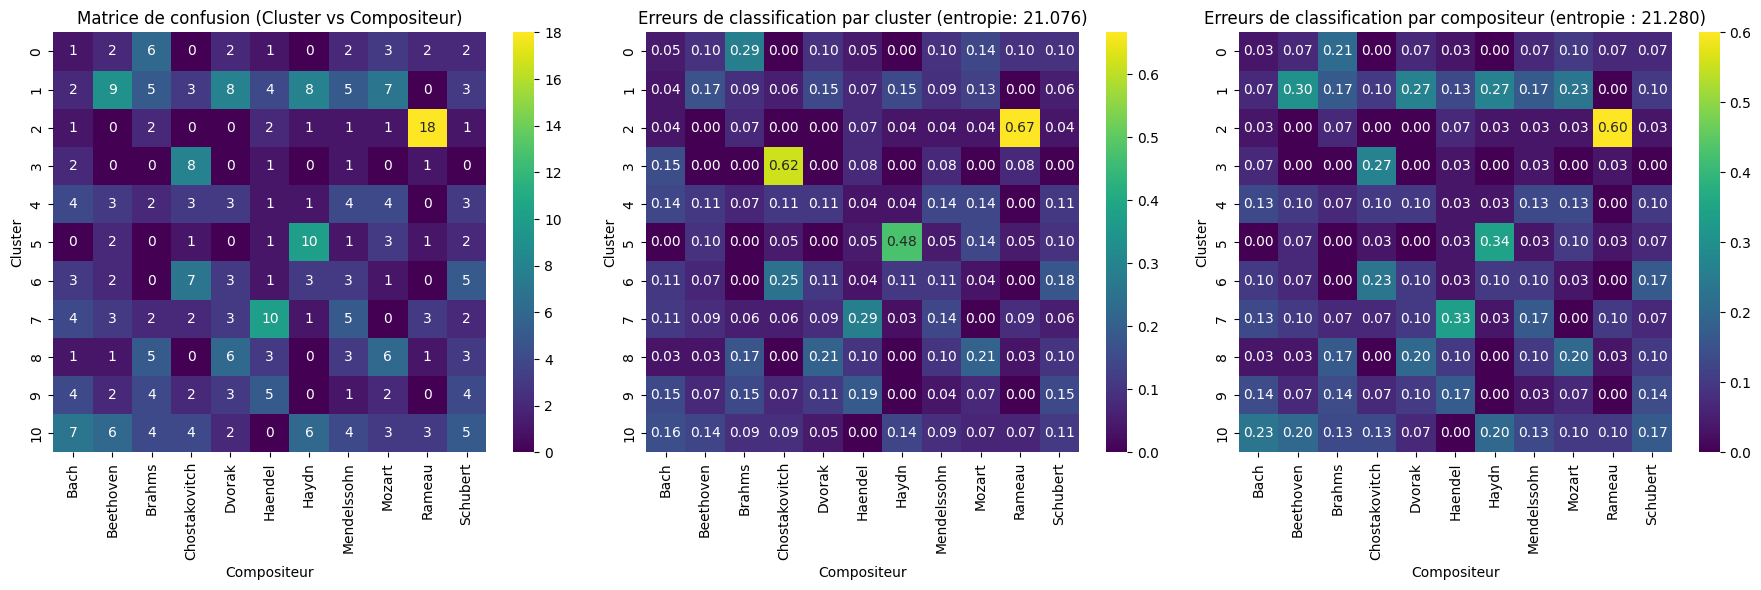

In [17]:
clustering_test(X,y,7)

c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



Entropie pour 1 dimensions : 20.592766423282935


c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



Entropie pour 2 dimensions : 22.77104917076886


c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



...

Entropie pour 8 dimensions : 21.200550651614172


c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



Entropie pour 9 dimensions : 21.50193164719196


c:\Log_inst\Programmation-Anaconda\envs\MODAL\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



Entropie pour 10 dimensions : 21.142760291822814


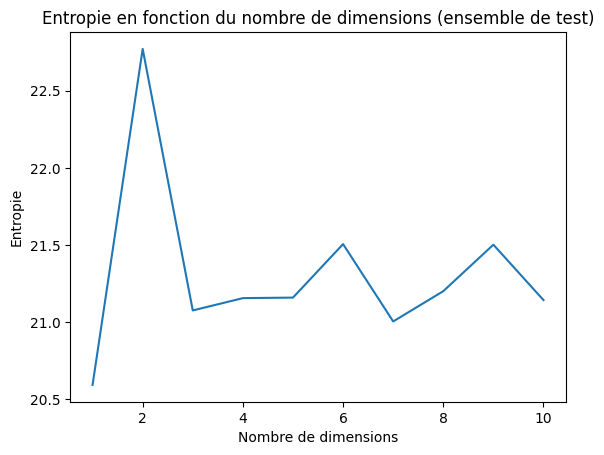

In [18]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement et de test
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.3, random_state=42, stratify=y)

entropies = []
for d in range(1, 11):
    lda = LDA(n_components=d)
    
    # Appliquer LDA sur l'ensemble d'entraînement
    X_train_lda = lda.fit_transform(X_train, y_train)
    X_test_lda = lda.transform(X_test)
    
    # Appliquer KMeans sur l'ensemble d'entraînement
    kmeans = KMeans(n_clusters=11, random_state=42)
    clusters = kmeans.fit_predict(X_train_lda)
    
    # Prédire les clusters pour l'ensemble de test
    test_clusters = kmeans.predict(X_test_lda)
    
    # Créer un DataFrame pour l'ensemble de test
    df_test = pd.DataFrame(data=X_test_lda)
    df_test['Class'] = y_test
    df_test['Cluster'] = test_clusters
    
    # Calculer les comptes cluster-compositeur pour l'ensemble de test
    cluster_composer_counts = df_test.groupby(['Cluster', 'Class']).size().unstack(fill_value=0)
    
    # Calculer l'entropie
    entrop = calcul_entropy(cluster_composer_counts)
    print(f"Entropie pour {d} dimensions : {entrop}")
    entropies.append(entrop)

# Tracer l'entropie en fonction du nombre de dimensions
plt.plot(range(1, 11), entropies)
plt.xlabel('Nombre de dimensions')
plt.ylabel('Entropie')
plt.title('Entropie en fonction du nombre de dimensions (ensemble de test)')
plt.show()